Loading dataset...
Original dataset shape: (344, 9)
Dataset shape after dropping NA values in used columns: (333, 7)

PART 1: NUMERICAL ATTRIBUTES ANALYSIS

Numerical data shape: (333, 4)

Descriptive statistics:
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      333.000000     333.000000         333.000000   333.000000
mean        43.992793      17.164865         200.966967  4207.057057
std          5.468668       1.969235          14.015765   805.215802
min         32.100000      13.100000         172.000000  2700.000000
25%         39.500000      15.600000         190.000000  3550.000000
50%         44.500000      17.300000         197.000000  4050.000000
75%         48.600000      18.700000         213.000000  4775.000000
max         59.600000      21.500000         231.000000  6300.000000

1. STANDARDIZING NUMERICAL DATA...

2. COMPUTING MEAN VECTOR...
Mean vector of standardized data:
bill_length_mm: -0.000000
bill_depth_mm: -0.000000
flipper_length_m

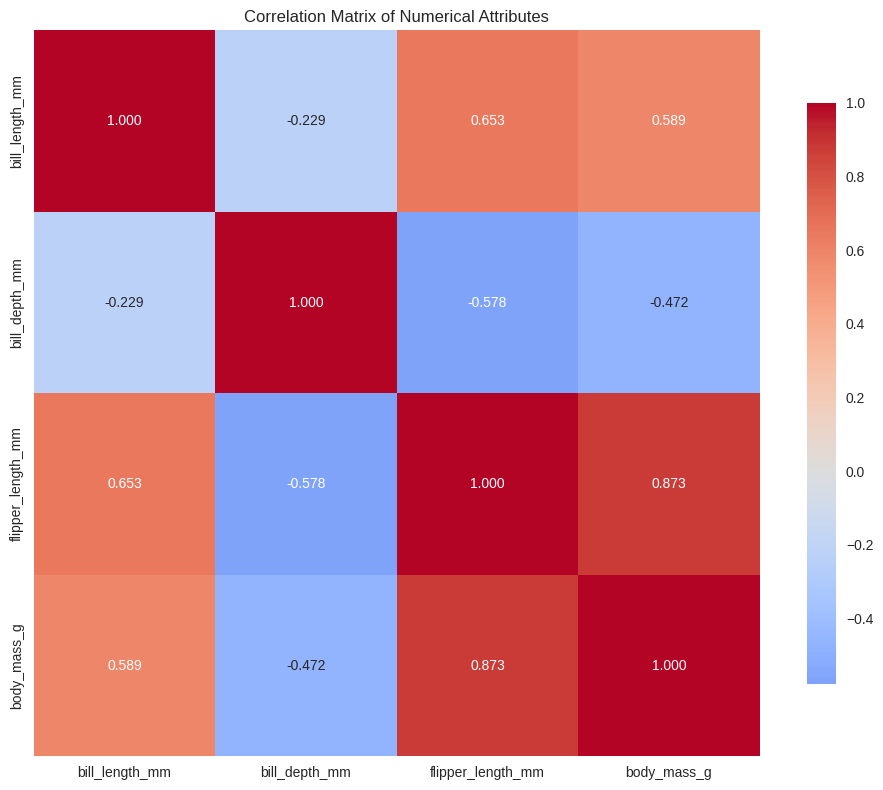


Strongest correlations (absolute value):
flipper_length_mm vs body_mass_g: 0.873 (positive)
bill_length_mm vs flipper_length_mm: 0.653 (positive)
bill_length_mm vs body_mass_g: 0.589 (positive)

7. COMPUTING KERNEL MATRICES...
Kernel matrix shapes:
Linear: (333, 333), Polynomial: (333, 333), RBF: (333, 333)


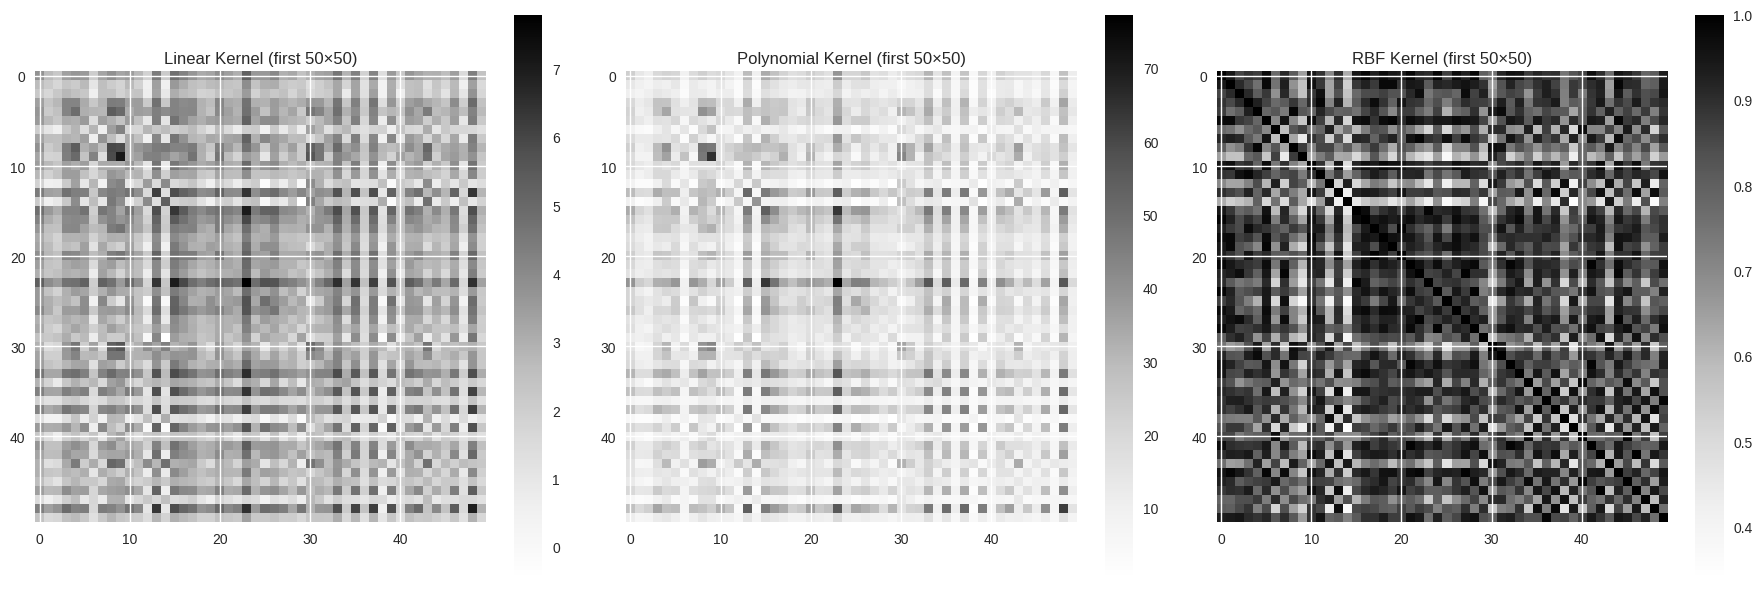


8. EIGEN ANALYSIS AND PROJECTION...
Eigenvalues of covariance matrix:
PC1: 2.7536
PC2: 0.7805
PC3: 0.3698
PC4: 0.1082

Principal component (eigenvector with largest eigenvalue):
bill_length_mm: -0.4538
bill_depth_mm: 0.3990
flipper_length_mm: -0.5768
body_mass_g: -0.5497


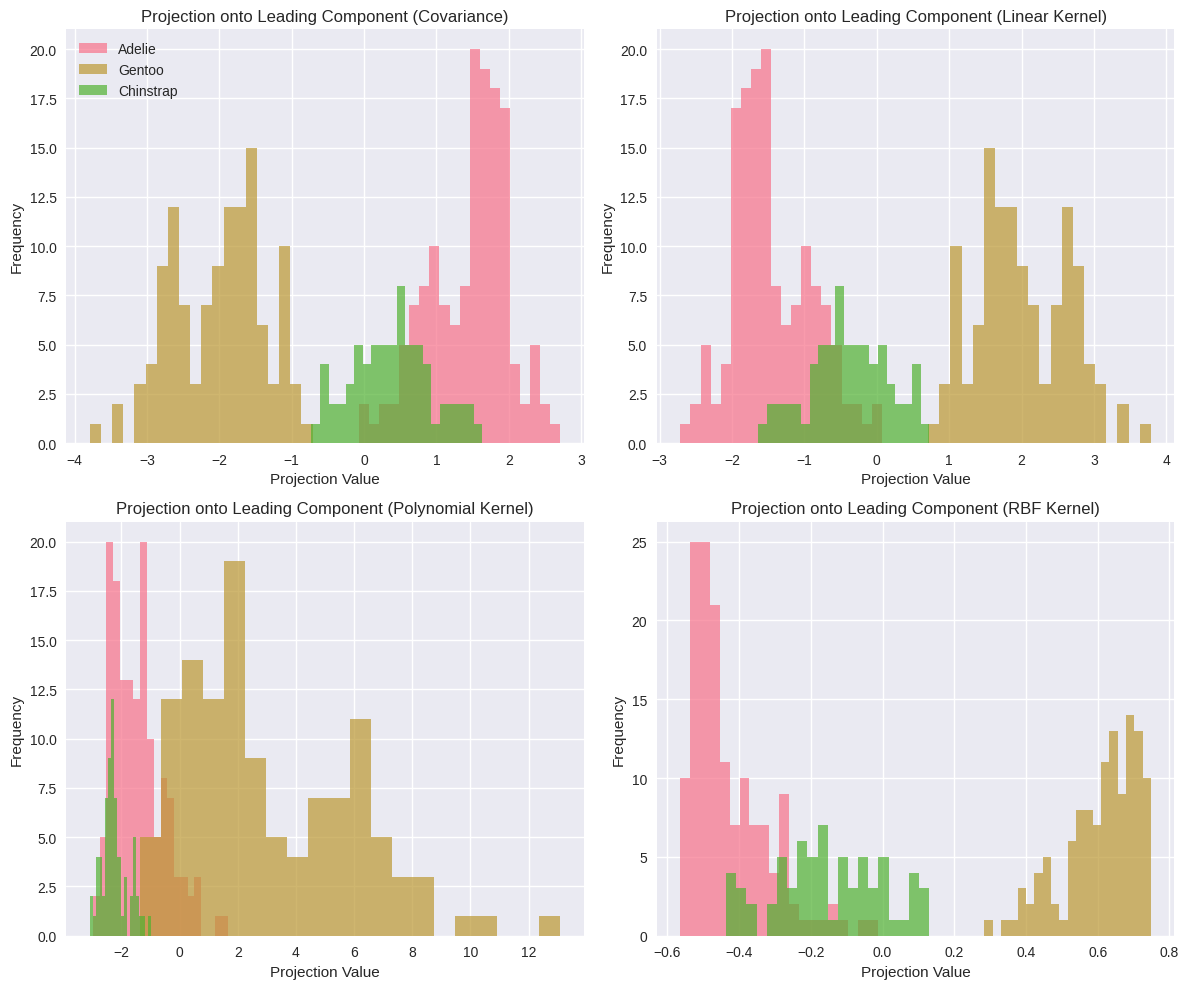


9. VISUALIZING NUMERICAL ATTRIBUTES...


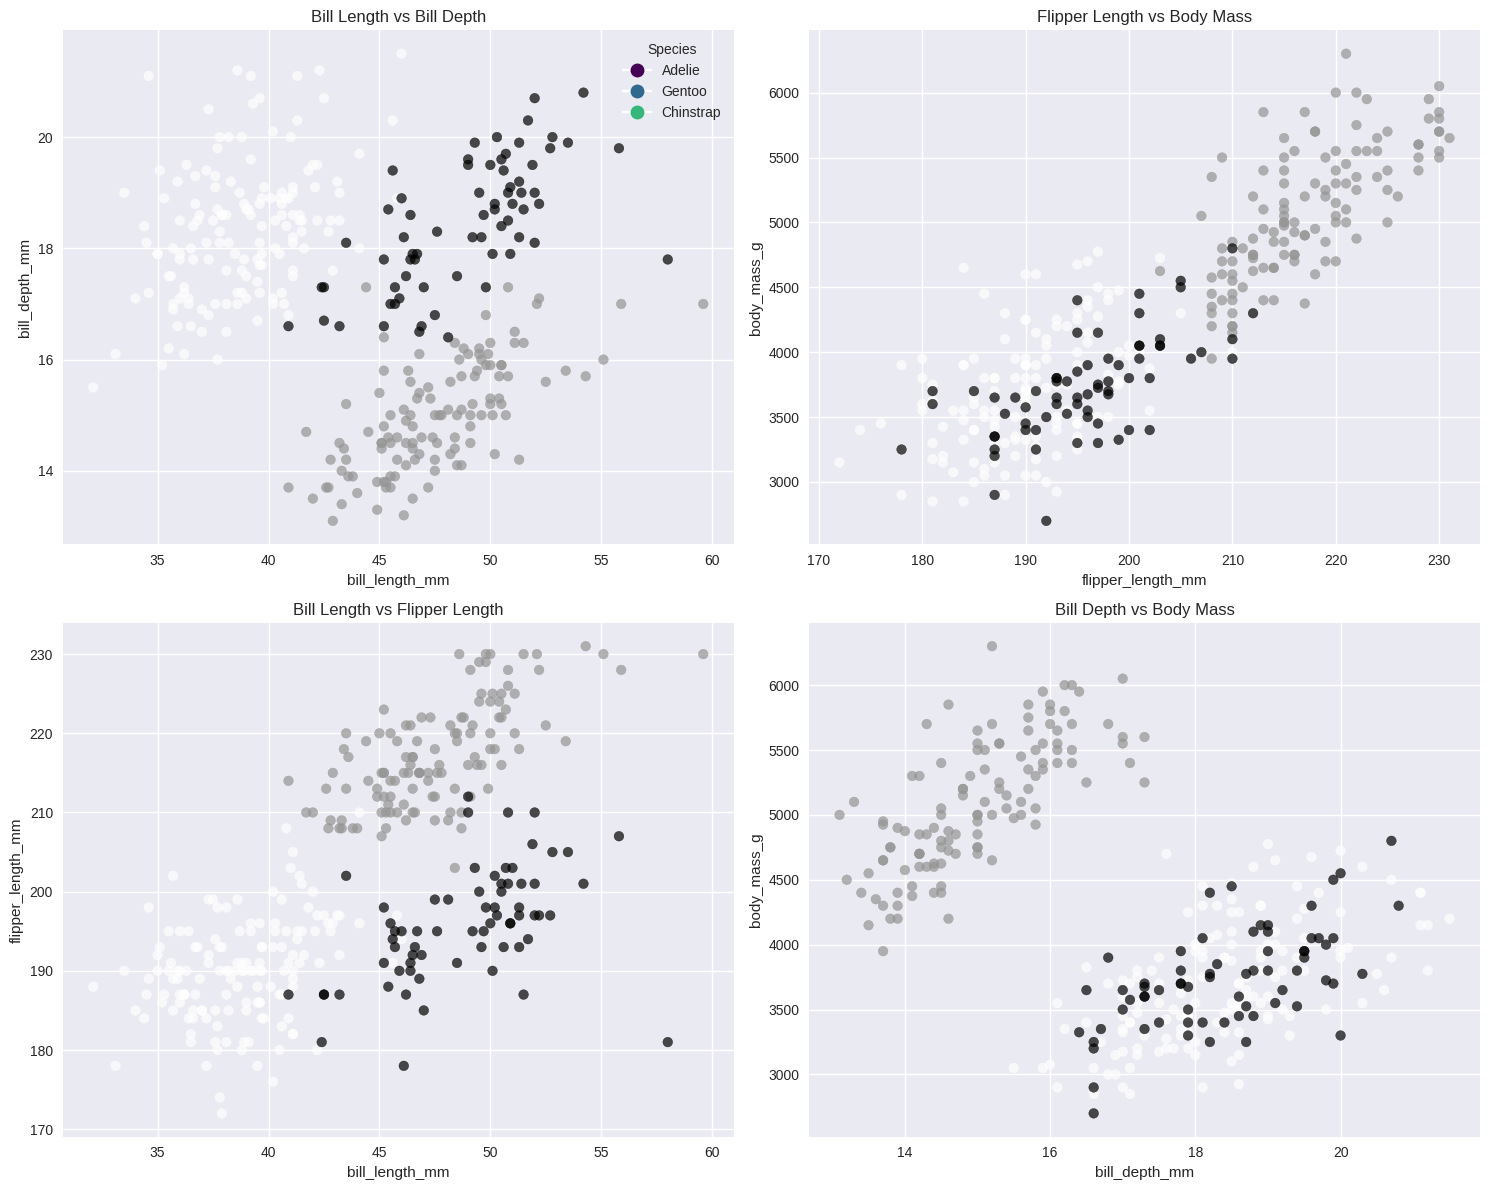


PART 2: CATEGORICAL ATTRIBUTES ANALYSIS

Categorical data shape: (333, 3)

Value counts for each categorical attribute:

species:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

island:
island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64

sex:
sex
male      168
female    165
Name: count, dtype: int64

1. COMPUTING MEAN VECTOR FOR CATEGORICAL ATTRIBUTES...
Mean vector (proportions) for categorical attributes:
species_Adelie: 0.438
species_Chinstrap: 0.204
species_Gentoo: 0.357
island_Biscoe: 0.489
island_Dream: 0.369
island_Torgersen: 0.141
sex_female: 0.495
sex_male: 0.505

INTERPRETATION:

species:
  Adelie: 0.438 (43.8%)
  Chinstrap: 0.204 (20.4%)
  Gentoo: 0.357 (35.7%)

island:
  Biscoe: 0.489 (48.9%)
  Dream: 0.369 (36.9%)
  Torgersen: 0.141 (14.1%)

sex:
  female: 0.495 (49.5%)
  male: 0.505 (50.5%)

2. COMPUTING COVARIANCE MATRIX FOR CATEGORICAL ATTRIBUTES (distributional measure)...

Categorical dependence m

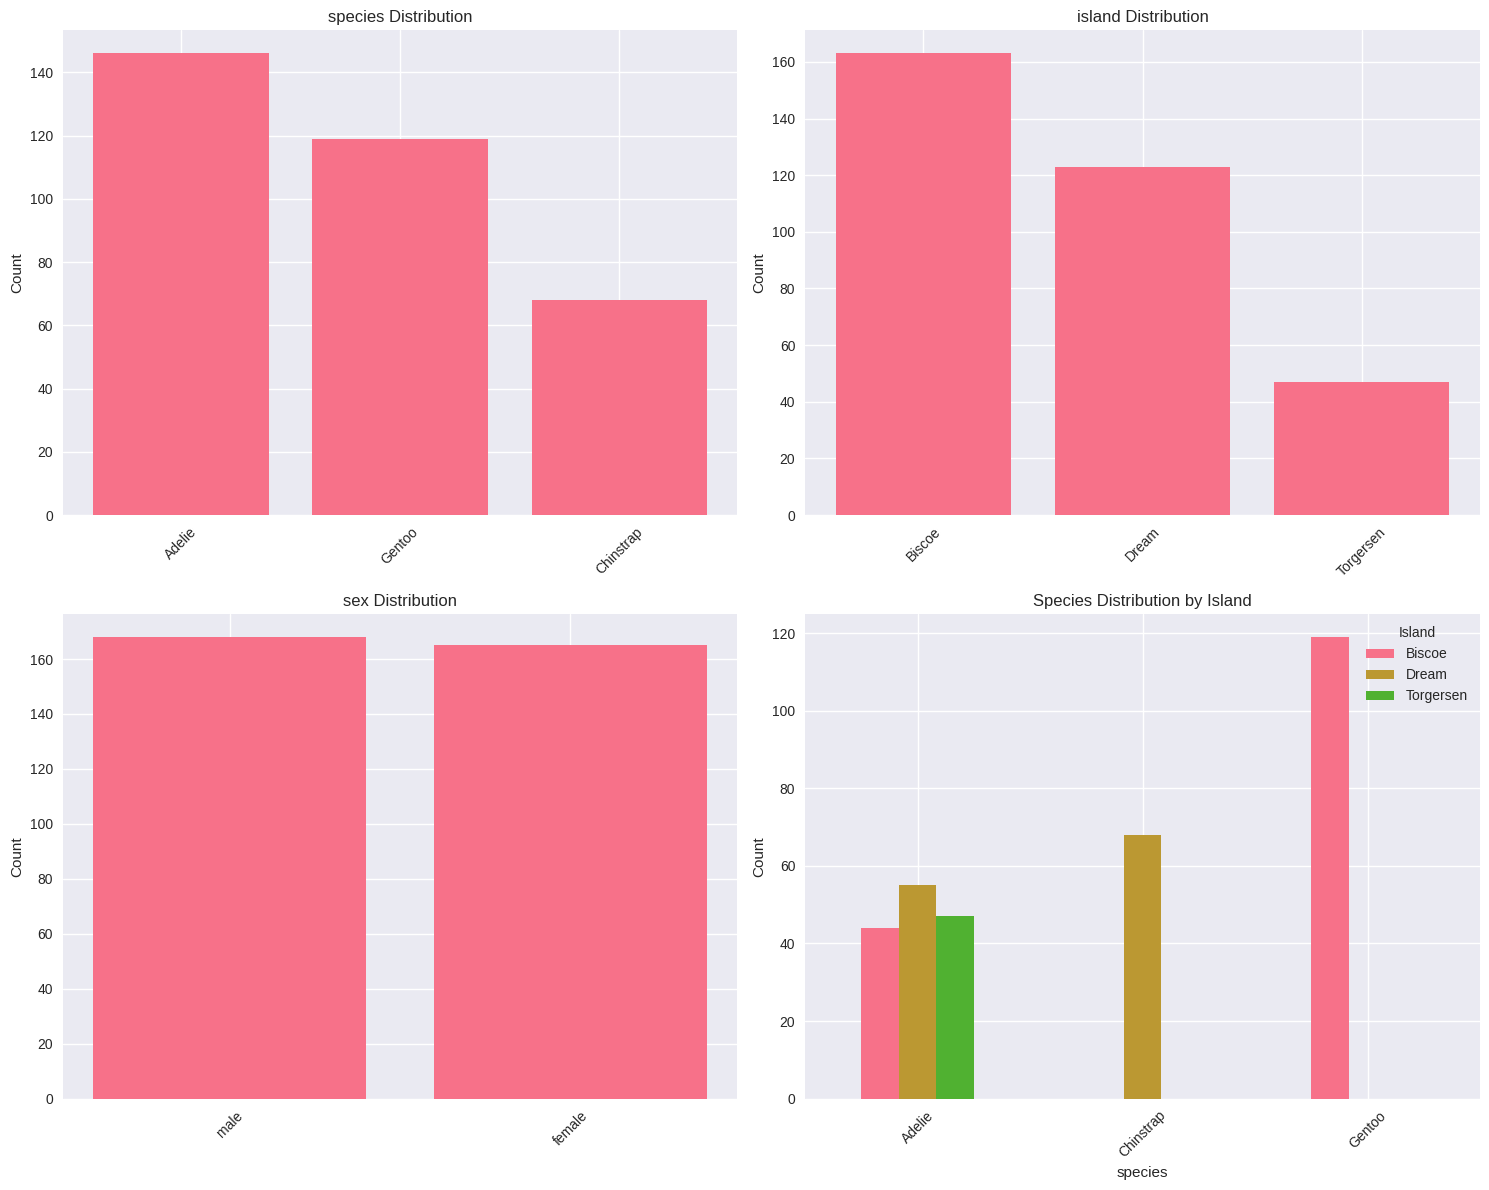

<Figure size 1000x600 with 0 Axes>

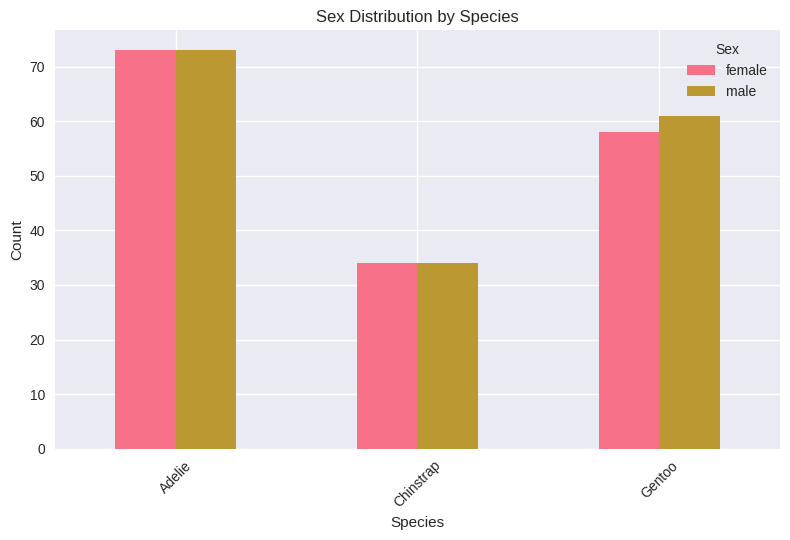


ANALYSIS COMPLETE!
All visualizations have been saved as PNG files.


In [ ]:
# Palmer Penguins Dataset Analysis
# Complete analysis of both numerical and categorical attributes

# Our necessary imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # OK to keep; see note below
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import polynomial_kernel, rbf_kernel, linear_kernel

# Set style for plots (if grader bans seaborn, comment these two lines)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


# Load Dataset & clean

print("Loading dataset...")
df = pd.read_csv('penguins.csv')
print(f"Original dataset shape: {df.shape}")

# Drop rows with any NA in columns we actually use (safer than full-row drop)
numerical_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
categorical_cols = ['species', 'island', 'sex']
df_clean = df[numerical_cols + categorical_cols].dropna().copy()
print(f"Dataset shape after dropping NA values in used columns: {df_clean.shape}")


# PART 1: NUMERICAL ATTRIBUTES ANALYSIS


print("\n" + "="*60)
print("PART 1: NUMERICAL ATTRIBUTES ANALYSIS")
print("="*60)

# Extract numerical
numerical_data = df_clean[numerical_cols].copy()
print(f"\nNumerical data shape: {numerical_data.shape}")
print("\nDescriptive statistics:")
print(numerical_data.describe())

# 1) Standardize
print("\n1. STANDARDIZING NUMERICAL DATA...")
scaler = StandardScaler()
Z = scaler.fit_transform(numerical_data)                      # standardized, mean~0, var~1
numerical_data_standardized = pd.DataFrame(Z, columns=numerical_cols)

# 2) Mean vector (on standardized data ~0)
print("\n2. COMPUTING MEAN VECTOR...")
mean_vector = numerical_data_standardized.mean().values
print("Mean vector of standardized data:")
for i, col in enumerate(numerical_cols):
    print(f"{col}: {mean_vector[i]:.6f}")

# 3) Centering (kinda redundant but required by the rubric)
print("\n3. CENTERING THE DATA...")
centered_data = numerical_data_standardized - mean_vector
new_mean = centered_data.mean().values
print("New mean after centering:")
for i, col in enumerate(numerical_cols):
    print(f"{col}: {new_mean[i]:.10f} (should be close to 0)")
print(f"Max deviation from zero: {np.max(np.abs(new_mean)):.10f}")

# 4) Covariance matrix (two ways)
print("\n4. COMPUTING COVARIANCE MATRIX...")
n, d = centered_data.shape

# Inner product formulation
cov_matrix_inner = (centered_data.T @ centered_data) / (n - 1)
print("Covariance matrix (inner product formulation):")
print(pd.DataFrame(cov_matrix_inner, index=numerical_cols, columns=numerical_cols))

# Outer product formulation
cov_matrix_outer = np.zeros((d, d))
for i in range(n):
    vec = centered_data.iloc[i].values.reshape(-1, 1)
    cov_matrix_outer += vec @ vec.T
cov_matrix_outer /= (n - 1)
print("\nCovariance matrix (outer product formulation):")
print(pd.DataFrame(cov_matrix_outer, index=numerical_cols, columns=numerical_cols))

print(f"\nMatrices are equivalent: {np.allclose(cov_matrix_inner, cov_matrix_outer)}")
print(f"Maximum difference: {np.max(np.abs(cov_matrix_inner - cov_matrix_outer)):.2e}")

# 5) Scatter matrix & relationship
print("\n5. COMPUTING SCATTER MATRIX...")
scatter_matrix = centered_data.T @ centered_data
print("Scatter matrix (standardized):")
print(pd.DataFrame(scatter_matrix, index=numerical_cols, columns=numerical_cols))
print("Check S = (n-1) * Cov  ->", np.allclose(scatter_matrix, (n - 1) * cov_matrix_inner))

# 6) Correlation matrix (on original features)
print("\n6. COMPUTING CORRELATION MATRIX...")
correlation_matrix = numerical_data.corr()
print("Correlation matrix:")
print(correlation_matrix)

# Heatmap (using seaborn bc I think it looks better).
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f', cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numerical Attributes')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Strongest correlations
print("\nStrongest correlations (absolute value):")
corr_pairs = []
for i in range(d):
    for j in range(i+1, d):
        col1, col2 = numerical_cols[i], numerical_cols[j]
        r = correlation_matrix.loc[col1, col2]
        corr_pairs.append((col1, col2, abs(r), r))
corr_pairs.sort(key=lambda x: x[2], reverse=True)
for col1, col2, abs_corr, r in corr_pairs[:3]:
    direction = "positive" if r > 0 else "negative"
    print(f"{col1} vs {col2}: {r:.3f} ({direction})")

# 7) Kernel matrices (on standardized Z)
print("\n7. COMPUTING KERNEL MATRICES...")
X = numerical_data_standardized.values

# Linear
K_linear = linear_kernel(X)  # = X @ X.T

# Polynomial (match formula (x^T y + 1)^2)
K_poly = polynomial_kernel(X, degree=2, gamma=1.0, coef0=1.0)  # <<< changed

# RBF with gamma=0.1 per instructions
K_rbf  = rbf_kernel(X, gamma=0.1)  # <<< changed

print("Kernel matrix shapes:")
print(f"Linear: {K_linear.shape}, Polynomial: {K_poly.shape}, RBF: {K_rbf.shape}")

# Visualize kernels (first 50x50 just for readability)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, K, name in zip(axes, [K_linear, K_poly, K_rbf], ['Linear', 'Polynomial', 'RBF']):
    im = ax.imshow(K[:50, :50])
    ax.set_title(f'{name} Kernel (first 50×50)')
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('kernel_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# 8) Eigen analysis & projections
print("\n8. EIGEN ANALYSIS AND PROJECTION...")

# Covariance eigen (use eigh for symmetric matrices)
w_cov, V_cov = np.linalg.eigh(cov_matrix_inner)  # <<< changed
idx = np.argsort(w_cov)[::-1]
w_cov, V_cov = w_cov[idx], V_cov[:, idx]

print("Eigenvalues of covariance matrix:")
for i, val in enumerate(w_cov):
    print(f"PC{i+1}: {val:.4f}")

principal_component = V_cov[:, 0]
print("\nPrincipal component (eigenvector with largest eigenvalue):")
for i, col in enumerate(numerical_cols):
    print(f"{col}: {principal_component[i]:.4f}")

# Projection of rows onto first PC
projection_cov = centered_data.values @ principal_component  # (n,)

# Kernel eigens (center K first) + scaled projections (sqrt(lambda))
def kernel_eigen_analysis(K):
    n = K.shape[0]
    J = np.ones((n, n)) / n
    Kc = K - J @ K - K @ J + J @ K @ J
    w, V = np.linalg.eigh((Kc + Kc.T) / 2.0)  # symmetry fix + eigh  <<< changed
    idx = np.argsort(w)[::-1]
    w, V = w[idx], V[:, idx]
    # scores along top component in kernel PCA space
    top_scores = V[:, 0] * np.sqrt(max(w[0], 0))  # <<< changed
    return w, V, top_scores

w_lin, V_lin, proj_lin = kernel_eigen_analysis(K_linear)
w_pol, V_pol, proj_pol = kernel_eigen_analysis(K_poly)
w_rbf, V_rbf, proj_rbf = kernel_eigen_analysis(K_rbf)

# Species for coloring (aligned to numerical rows)
species_for_plot = df_clean.loc[numerical_data.index, 'species']  # <<< changed

# Compare projections (hist by species)
plt.figure(figsize=(12, 10))
projections = [projection_cov, proj_lin, proj_pol, proj_rbf]
titles = ['Covariance', 'Linear Kernel', 'Polynomial Kernel', 'RBF Kernel']

for i, (proj, title) in enumerate(zip(projections, titles)):
    plt.subplot(2, 2, i+1)
    for sp in species_for_plot.unique():
        mask = (species_for_plot == sp).values
        plt.hist(proj[mask], alpha=0.7, bins=20, label=sp)
    plt.title(f'Projection onto Leading Component ({title})')
    plt.xlabel('Projection Value'); plt.ylabel('Frequency')
    if i == 0:
        plt.legend()
plt.tight_layout()
plt.savefig('projection_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 9) Numerical attribute scatter plots
print("\n9. VISUALIZING NUMERICAL ATTRIBUTES...")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
pairs = [
    ('bill_length_mm', 'bill_depth_mm', 'Bill Length vs Bill Depth'),
    ('flipper_length_mm', 'body_mass_g', 'Flipper Length vs Body Mass'),
    ('bill_length_mm', 'flipper_length_mm', 'Bill Length vs Flipper Length'),
    ('bill_depth_mm', 'body_mass_g', 'Bill Depth vs Body Mass')
]
colors = pd.factorize(species_for_plot)[0]

for i, (x_col, y_col, title) in enumerate(pairs):
    r, c = divmod(i, 2)
    sc = axes[r, c].scatter(numerical_data[x_col], numerical_data[y_col],
                            c=colors, alpha=0.7)
    axes[r, c].set_xlabel(x_col); axes[r, c].set_ylabel(y_col); axes[r, c].set_title(title)
    if i == 0:
        handles, labels = [], []
        unique_species = species_for_plot.unique()
        for j, sp in enumerate(unique_species):
            handles.append(plt.Line2D([0], [0], marker='o', color='w',
                                      markerfacecolor=plt.cm.viridis(j/len(unique_species)),
                                      markersize=10))
            labels.append(sp)
        axes[r, c].legend(handles, labels, title="Species")

plt.tight_layout()
plt.savefig('numerical_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# PART 2: CATEGORICAL ATTRIBUTES ANALYSIS

print("\n" + "="*60)
print("PART 2: CATEGORICAL ATTRIBUTES ANALYSIS")
print("="*60)

categorical_data = df_clean[categorical_cols].copy()
print(f"\nCategorical data shape: {categorical_data.shape}")
print("\nValue counts for each categorical attribute:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(categorical_data[col].value_counts())

# 1) Mean vector (relative frequencies)
print("\n1. COMPUTING MEAN VECTOR FOR CATEGORICAL ATTRIBUTES...")
one_hot_data = pd.get_dummies(categorical_data)
mean_vector_categorical = one_hot_data.mean()

print("Mean vector (proportions) for categorical attributes:")
for col in one_hot_data.columns:
    print(f"{col}: {mean_vector_categorical[col]:.3f}")

print("\nINTERPRETATION:")
for col in categorical_cols:
    cols = [c for c in one_hot_data.columns if c.startswith(col + '_')]
    print(f"\n{col}:")
    for c in cols:
        cat = c.split('_', 1)[1]
        p = mean_vector_categorical[c]
        print(f"  {cat}: {p:.3f} ({p*100:.1f}%)")

# 2) Categorical "covariance" (3x3) based on distribution dependence
print("\n2. COMPUTING COVARIANCE MATRIX FOR CATEGORICAL ATTRIBUTES (distributional measure)...")

def covcat_squared_l2(A: pd.Series, B: pd.Series) -> float:
    ct = pd.crosstab(A, B, normalize=True)            # P(i,j)
    pA = ct.sum(axis=1).values.reshape(-1, 1)          # P(i)
    pB = ct.sum(axis=0).values.reshape(1, -1)          # P(j)
    expected = pA @ pB                                 # P(i)P(j)
    diff2 = (ct.values - expected) ** 2
    return float(diff2.sum())

cats = categorical_cols
covcat = pd.DataFrame(np.eye(3)*0.0, index=cats, columns=cats)
for i in range(3):
    for j in range(i+1, 3):
        v = covcat_squared_l2(categorical_data[cats[i]], categorical_data[cats[j]])
        covcat.iloc[i, j] = covcat.iloc[j, i] = v
print("\nCategorical dependence matrix (0 = independent, larger = stronger association):")
print(covcat.round(6))

# 3) Our Visualizations
print("\n3. VISUALIZING CATEGORICAL ATTRIBUTES...")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Individual bar plots
for i, col in enumerate(categorical_cols):
    r, c = divmod(i, 2)
    counts = categorical_data[col].value_counts()
    axes[r, c].bar(counts.index, counts.values)
    axes[r, c].set_title(f'{col} Distribution')
    axes[r, c].set_ylabel('Count')
    axes[r, c].tick_params(axis='x', rotation=45)

# Grouped: species vs island
cross_tab = pd.crosstab(categorical_data['species'], categorical_data['island'])
cross_tab.plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Species Distribution by Island')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(title='Island')

plt.tight_layout()
plt.savefig('categorical_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# Just Additional: sex distribution per species
plt.figure(figsize=(10, 6))
cross_tab_sex = pd.crosstab(categorical_data['species'], categorical_data['sex'])
cross_tab_sex.plot(kind='bar')
plt.title('Sex Distribution by Species')
plt.ylabel('Count'); plt.xlabel('Species')
plt.xticks(rotation=45); plt.legend(title='Sex')
plt.tight_layout()
plt.savefig('sex_by_species.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nANALYSIS COMPLETE!")
print("All visualizations have been saved as PNG files.")
